In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [30]:
df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/multiclass_classification_dataset_500_samples.csv')

In [31]:
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,Medium,Yes,B,1
1,19.31,94.09,81.10,56.73,Low,Yes,B,1
2,23.24,61.01,70.72,52.73,Medium,Yes,A,0
3,27.62,80.63,62.24,64.95,Low,Yes,C,0
4,18.83,68.49,78.38,62.45,High,Yes,B,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            500 non-null    float64
 1   Attendance_Percentage  500 non-null    float64
 2   Assignment_Score       500 non-null    float64
 3   Internal_Marks         500 non-null    float64
 4   Participation          500 non-null    object 
 5   Internet_Access        500 non-null    object 
 6   Previous_Grade         500 non-null    object 
 7   Performance_Level      500 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 31.4+ KB


In [33]:
le = LabelEncoder()
df['Participation'] = le.fit_transform(df['Participation'])
df['Internet_Access'] = le.fit_transform(df['Internet_Access'])
df['Previous_Grade'] = le.fit_transform(df['Previous_Grade'])

In [34]:
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,2,1,1,1
1,19.31,94.09,81.10,56.73,1,1,1,1
2,23.24,61.01,70.72,52.73,2,1,0,0
3,27.62,80.63,62.24,64.95,1,1,2,0
4,18.83,68.49,78.38,62.45,0,1,1,0


In [35]:
X = df.drop('Performance_Level', axis=1)
y = df['Performance_Level']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
lr = LogisticRegression(multi_class='multinomial', max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [39]:
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, lr_pred, average='macro'):.4f}")

Accuracy:  0.9700
Precision: 0.6474
Recall:    0.6599
F1-Score:  0.6533


In [40]:
print('Classification Report for Logistic Regression:')
print(classification_report(y_test, lr_pred, zero_division=0))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.94      1.00      0.97        49
           2       0.00      0.00      0.00         2

    accuracy                           0.97       100
   macro avg       0.65      0.66      0.65       100
weighted avg       0.95      0.97      0.96       100



In [41]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [42]:
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, dt_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, dt_pred, average='macro'):.4f}")

Accuracy:  0.9000
Precision: 0.9320
Recall:    0.9320
F1-Score:  0.9320


In [43]:
print('Classification Report for Decision Tree:')
print(classification_report(y_test, dt_pred, zero_division=0))

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        49
           1       0.90      0.90      0.90        49
           2       1.00      1.00      1.00         2

    accuracy                           0.90       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.90      0.90      0.90       100



In [44]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [45]:
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_pred, average='macro'):.4f}")

Accuracy:  0.9400
Precision: 0.6269
Recall:    0.6395
F1-Score:  0.6331


In [46]:
print('Classification Report for Random Forest:')
print(classification_report(y_test, rf_pred, zero_division=0))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        49
           1       0.92      0.96      0.94        49
           2       0.00      0.00      0.00         2

    accuracy                           0.94       100
   macro avg       0.63      0.64      0.63       100
weighted avg       0.92      0.94      0.93       100



In [47]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [48]:
print(f"Accuracy:  {accuracy_score(y_test, gb_pred):.4f}")
print(f"Precision: {precision_score(y_test, gb_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, gb_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, gb_pred, average='macro'):.4f}")

Accuracy:  0.9500
Precision: 0.9661
Recall:    0.9660
F1-Score:  0.9660


In [49]:
print('Classification Report for Gradient Boosting:')
print(classification_report(y_test, gb_pred, zero_division=0))

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        49
           1       0.96      0.94      0.95        49
           2       1.00      1.00      1.00         2

    accuracy                           0.95       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.95      0.95      0.95       100



In [50]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

In [51]:
print(f"Accuracy:  {accuracy_score(y_test, knn_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, knn_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, knn_pred, average='macro'):.4f}")

Accuracy:  0.7900
Precision: 0.5272
Recall:    0.5374
F1-Score:  0.5321


In [52]:
print('Classification Report for K-Nearest Neighbors:')
print(classification_report(y_test, knn_pred, zero_division=0))

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80        49
           1       0.77      0.82      0.79        49
           2       0.00      0.00      0.00         2

    accuracy                           0.79       100
   macro avg       0.53      0.54      0.53       100
weighted avg       0.78      0.79      0.78       100



### Saving the trained models

Accuracy:  0.9700
Precision: 0.6474
Recall:    0.6599
F1-Score:  0.6533


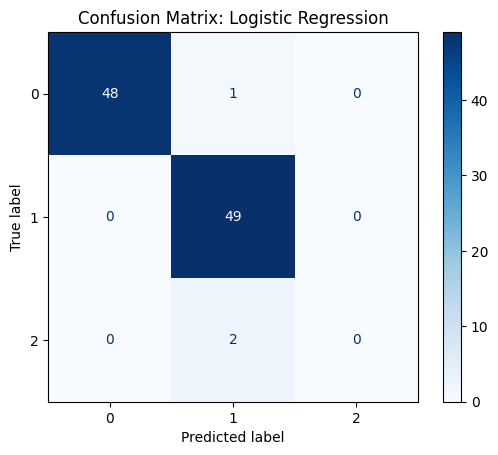

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

LR_pred = lr_pred

print(f"Accuracy:  {accuracy_score(y_test, LR_pred):.4f}")
print(f"Precision: {precision_score(y_test, LR_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, LR_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, LR_pred, average='macro'):.4f}")

cm_lr = confusion_matrix(y_test, LR_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

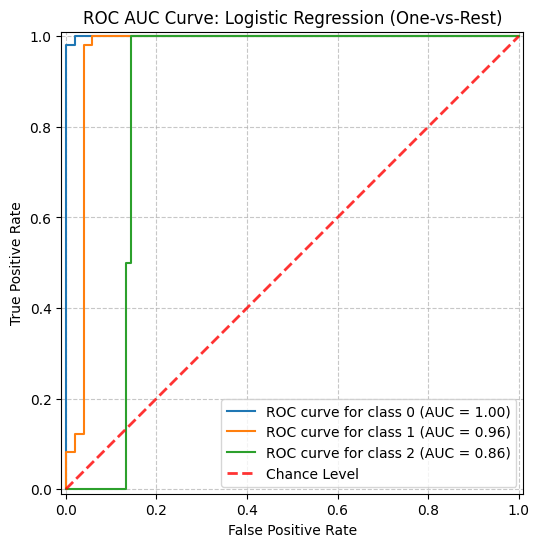

In [54]:
y_pred_proba_lr = lr.predict_proba(X_test_scaled)
classes = np.unique(y_test)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)

fig_lr, ax_lr = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_pred_proba_lr[:, i],
        name=f'ROC curve for class {classes[i]}',
        ax=ax_lr,
    )

ax_lr.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance Level', alpha=.8)
ax_lr.set_title('ROC AUC Curve: Logistic Regression (One-vs-Rest)')
ax_lr.set_xlabel('False Positive Rate')
ax_lr.set_ylabel('True Positive Rate')
ax_lr.grid(linestyle='--', alpha=0.7)
ax_lr.legend(loc='lower right')
plt.show()

Accuracy:  0.9000
Precision: 0.9320
Recall:    0.9320
F1-Score:  0.9320


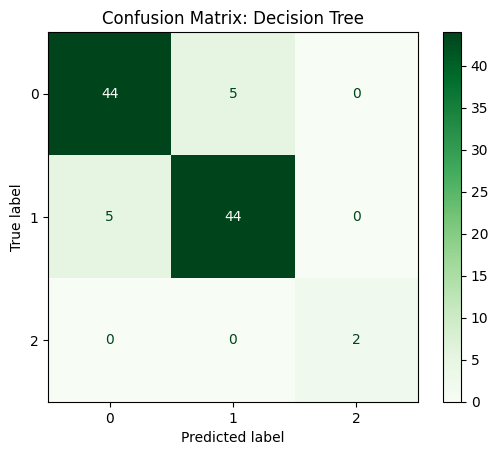

In [55]:
DT_pred = dt_pred

print(f"Accuracy:  {accuracy_score(y_test, DT_pred):.4f}")
print(f"Precision: {precision_score(y_test, DT_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, DT_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, DT_pred, average='macro'):.4f}")

cm_dt = confusion_matrix(y_test, DT_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap='Greens')
plt.title('Confusion Matrix: Decision Tree')
plt.show()

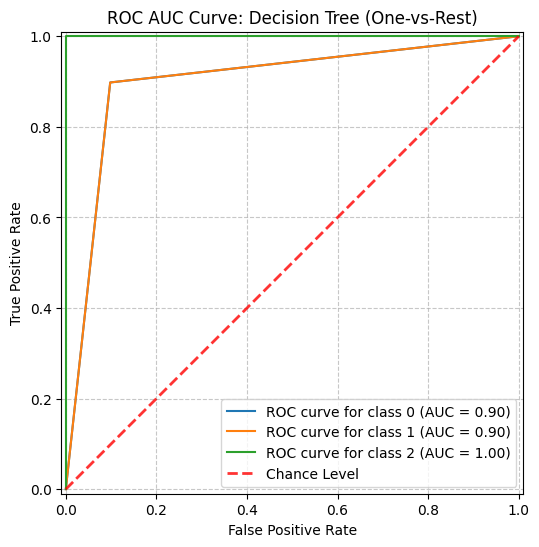

In [56]:
y_pred_proba_dt = dt.predict_proba(X_test)
classes = np.unique(y_test)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)

fig_dt, ax_dt = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_pred_proba_dt[:, i],
        name=f'ROC curve for class {classes[i]}',
        ax=ax_dt,
    )

ax_dt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance Level', alpha=.8)
ax_dt.set_title('ROC AUC Curve: Decision Tree (One-vs-Rest)')
ax_dt.set_xlabel('False Positive Rate')
ax_dt.set_ylabel('True Positive Rate')
ax_dt.grid(linestyle='--', alpha=0.7)
ax_dt.legend(loc='lower right')
plt.show()

Accuracy:  0.9400
Precision: 0.6269
Recall:    0.6395
F1-Score:  0.6331


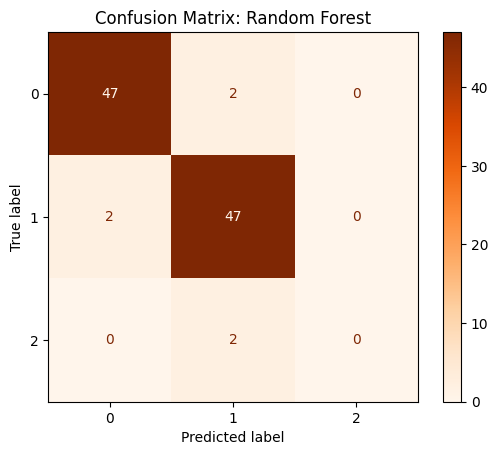

In [57]:
RF_pred = rf_pred

print(f"Accuracy:  {accuracy_score(y_test, RF_pred):.4f}")
print(f"Precision: {precision_score(y_test, RF_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, RF_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, RF_pred, average='macro'):.4f}")

cm_rf = confusion_matrix(y_test, RF_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Oranges')
plt.title('Confusion Matrix: Random Forest')
plt.show()

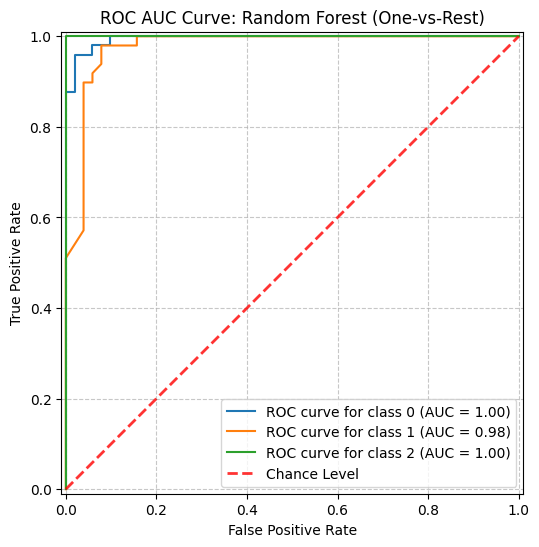

In [58]:
y_pred_proba_rf = rf.predict_proba(X_test)
classes = np.unique(y_test)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)

fig_rf, ax_rf = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_pred_proba_rf[:, i],
        name=f'ROC curve for class {classes[i]}',
        ax=ax_rf,
    )

ax_rf.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance Level', alpha=.8)
ax_rf.set_title('ROC AUC Curve: Random Forest (One-vs-Rest)')
ax_rf.set_xlabel('False Positive Rate')
ax_rf.set_ylabel('True Positive Rate')
ax_rf.grid(linestyle='--', alpha=0.7)
ax_rf.legend(loc='lower right')
plt.show()

Accuracy:  0.9500
Precision: 0.9661
Recall:    0.9660
F1-Score:  0.9660


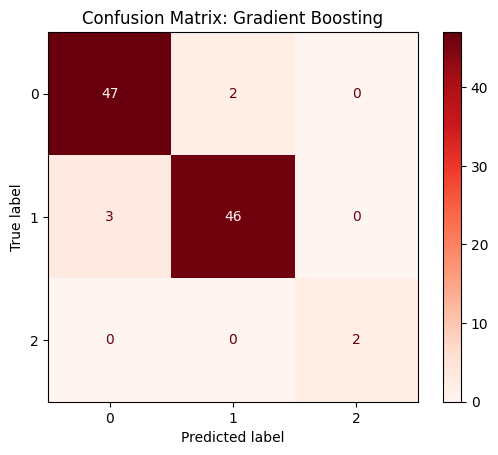

In [59]:
GB_pred = gb_pred

print(f"Accuracy:  {accuracy_score(y_test, GB_pred):.4f}")
print(f"Precision: {precision_score(y_test, GB_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, GB_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, GB_pred, average='macro'):.4f}")

cm_gb = confusion_matrix(y_test, GB_pred)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot(cmap='Reds')
plt.title('Confusion Matrix: Gradient Boosting')
plt.show()

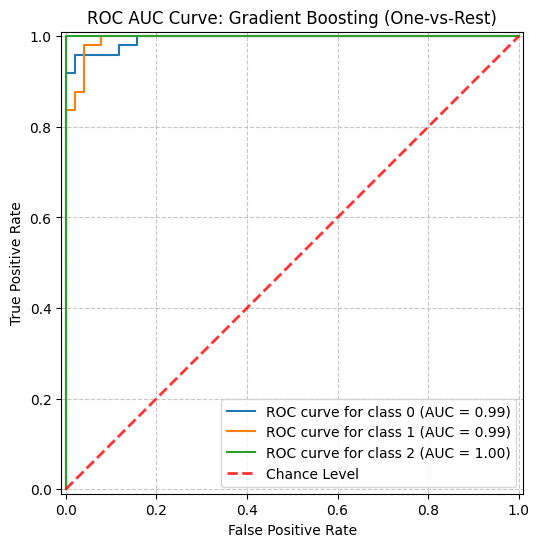

In [60]:
y_pred_proba_gb = gb.predict_proba(X_test)
classes = np.unique(y_test)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)

fig_gb, ax_gb = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_pred_proba_gb[:, i],
        name=f'ROC curve for class {classes[i]}',
        ax=ax_gb,
    )

ax_gb.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance Level', alpha=.8)
ax_gb.set_title('ROC AUC Curve: Gradient Boosting (One-vs-Rest)')
ax_gb.set_xlabel('False Positive Rate')
ax_gb.set_ylabel('True Positive Rate')
ax_gb.grid(linestyle='--', alpha=0.7)
ax_gb.legend(loc='lower right')
plt.show()

Accuracy:  0.7900
Precision: 0.5272
Recall:    0.5374
F1-Score:  0.5321


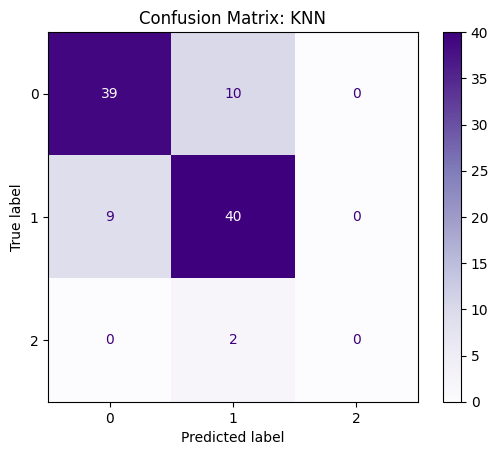

In [61]:
KNN_pred = knn_pred

print(f"Accuracy:  {accuracy_score(y_test, KNN_pred):.4f}")
print(f"Precision: {precision_score(y_test, KNN_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, KNN_pred, average='macro'):.4f}")
print(f"F1-Score:  {f1_score(y_test, KNN_pred, average='macro'):.4f}")

cm_knn = confusion_matrix(y_test, KNN_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(cmap='Purples')
plt.title('Confusion Matrix: KNN')
plt.show()

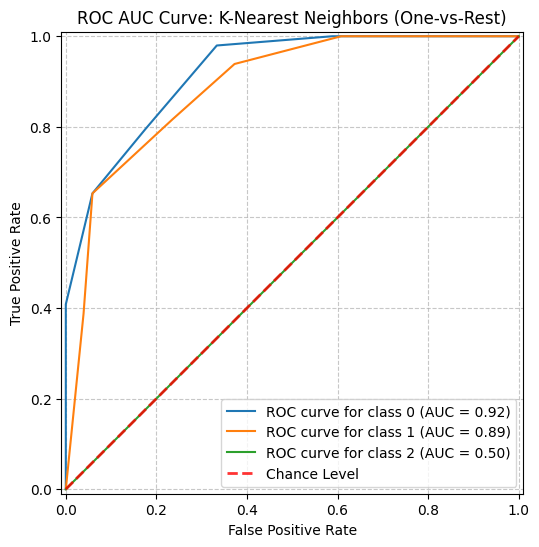

In [62]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
y_pred_proba_knn = knn.predict_proba(X_test_scaled)
classes = np.unique(y_test)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        y_pred_proba_knn[:, i],
        name=f'ROC curve for class {classes[i]}',
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance Level', alpha=.8)
ax.set_title('ROC AUC Curve: K-Nearest Neighbors (One-vs-Rest)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.grid(linestyle='--', alpha=0.7)
ax.legend(loc='lower right')
plt.show()

## Comparative Analysis of Model Performance

In [63]:
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'K-Nearest Neighbors']

accuracy_scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, knn_pred)
]

precision_scores = [
    precision_score(y_test, lr_pred, average='macro', zero_division=0),
    precision_score(y_test, dt_pred, average='macro', zero_division=0),
    precision_score(y_test, rf_pred, average='macro', zero_division=0),
    precision_score(y_test, gb_pred, average='macro', zero_division=0),
    precision_score(y_test, knn_pred, average='macro', zero_division=0)
]

recall_scores = [
    recall_score(y_test, lr_pred, average='macro'),
    recall_score(y_test, dt_pred, average='macro'),
    recall_score(y_test, rf_pred, average='macro'),
    recall_score(y_test, gb_pred, average='macro'),
    recall_score(y_test, knn_pred, average='macro')
]

f1_scores = [
    f1_score(y_test, lr_pred, average='macro'),
    f1_score(y_test, dt_pred, average='macro'),
    f1_score(y_test, rf_pred, average='macro'),
    f1_score(y_test, gb_pred, average='macro'),
    f1_score(y_test, knn_pred, average='macro')
]

performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

print("Model Performance Summary:")
display(performance_df)


Model Performance Summary:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.97,0.647436,0.659864,0.653329
1,Decision Tree,0.90,0.931973,0.931973,0.931973
2,Random Forest,0.94,0.626917,0.639456,0.633061
3,Gradient Boosting,0.95,0.966111,0.965986,0.965983
4,K-Nearest Neighbors,0.79,0.527244,0.537415,0.532068


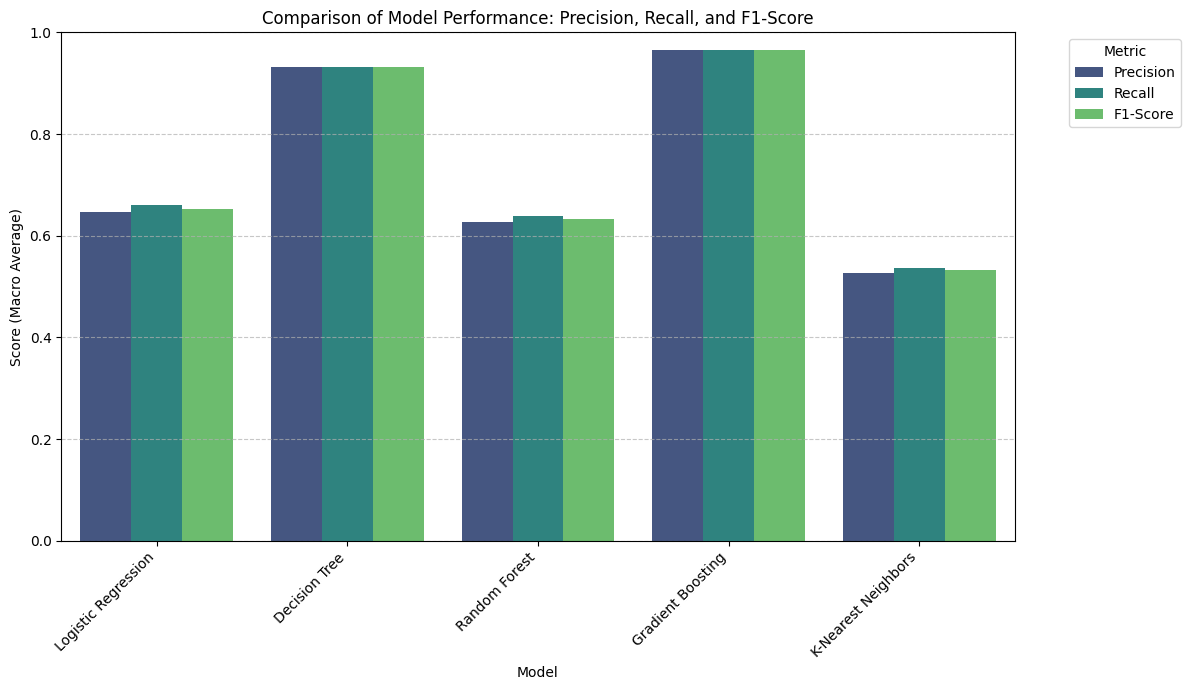

In [64]:
performance_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score', value_vars=['Precision', 'Recall', 'F1-Score'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=performance_melted, palette='viridis')
plt.title('Comparison of Model Performance: Precision, Recall, and F1-Score')
plt.ylabel('Score (Macro Average)')
plt.xlabel('Model')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pickle

output_dir = '/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/Exp8_models'

with open(os.path.join(output_dir, 'Logistic_Regression_model.pkl'), 'wb') as file:
    pickle.dump(lr, file)
with open(os.path.join(output_dir, 'Decision_Tree_model.pkl'), 'wb') as file:
    pickle.dump(dt, file)
with open(os.path.join(output_dir, 'Random_Forest_model.pkl'), 'wb') as file:
    pickle.dump(rf, file)
with open(os.path.join(output_dir, 'Gradient_Boosting_model.pkl'), 'wb') as file:
    pickle.dump(gb, file)
with open(os.path.join(output_dir, 'K_Nearest_Neighbors_model.pkl'), 'wb') as file:
    pickle.dump(knn, file)